# Analyse und Vorhersage des Veloverkehrs in Winterthur

In diesem Projekt werden öffentliche Veloverkehrsdaten der Stadt Winterthur analysiert. Ziel ist es, zeitliche Muster im Veloverkehr zu erkennen und mit einfachen Machine-Learning-Modellen die Anzahl gezählter Velos pro Messintervall vorherzusagen.

Das Projekt umfasst Datenaufbereitung, Feature Engineering, explorative Datenanalyse, Modellvergleich, Hyperparameter-Tuning und Evaluation.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score

## 1. Daten laden

Zuerst wird der Datensatz eingelesen. Die Daten enthalten Messungen des Veloverkehrs in Winterthur, unter anderem Informationen zur Zählstelle, Fahrtrichtung, Zeitstempel, Koordinaten und zur Anzahl gezählter Velos.

In [3]:
data = pd.read_csv("../data/winterthur_bike.csv")


## 2. Erste Datenübersicht

Die erste Prüfung zeigt, welche Spalten im Datensatz enthalten sind und welche Datentypen verwendet werden. Besonders relevant für die Analyse sind die Zeitspalten `zeit_von` und `zeit_bis` sowie die Zielvariable `anzahl`.

Die Spalte `anzahl` beschreibt die Anzahl gezählter Velos pro Messintervall. Ein Messintervall entspricht in diesem Datensatz ungefähr einer Stunde pro Zählstelle und Fahrtrichtung.

In [4]:
data.head()

,gemeinde_bfs_nr,gemeinde,anlage_nr,anlage_name,anlage_typ,zeit_von,zeit_bis,richtung,richtung_name,spur_nr,lat,lon,anzahl
0,230,Winterthur,bda81f33d038f8d70122e7f481b53020,Unterführung Bahnhof,Velo,2026-06-10T23:00:00+01,2026-06-10T23:59:59+01,O,Richtung Unterführung raus,2.0,47.500640,8.725399,20
1,230,Winterthur,bda81f33d038f8d70122e7f481b53020,Unterführung Bahnhof,Velo,2026-06-10T23:00:00+01,2026-06-10T23:59:59+01,W,Richtung Unterführung rein,1.0,47.500640,8.725399,9
2,230,Winterthur,89ec9c99764a468aef714df37cfbd83f,K501 Velo - Seenerstrasse,Velo,2026-06-10T23:00:00+01,2026-06-10T23:59:59+01,N,Richtung Oberwinterthur,2.0,47.493335,8.760645,0
3,230,Winterthur,89ec9c99764a468aef714df37cfbd83f,K501 Velo - Seenerstrasse,Velo,2026-06-10T23:00:00+01,2026-06-10T23:59:59+01,S,Richtung Seen,1.0,47.493335,8.760645,4
4,230,Winterthur,0790984be7042b7cba782aa0a73f7ae4,Frohbergstrasse,Velo,2026-06-10T23:00:00+01,2026-06-10T23:59:59+01,-,Richtung Meisenstrasse,2.0,47.497110,8.726561,3


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109776 entries, 0 to 109775
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   gemeinde_bfs_nr  109776 non-null  int64  
 1   gemeinde         109776 non-null  object 
 2   anlage_nr        109776 non-null  object 
 3   anlage_name      109776 non-null  object 
 4   anlage_typ       109776 non-null  object 
 5   zeit_von         109776 non-null  object 
 6   zeit_bis         109776 non-null  object 
 7   richtung         109776 non-null  object 
 8   richtung_name    109776 non-null  object 
 9   spur_nr          109776 non-null  float64
 10  lat              109776 non-null  float64
 11  lon              109776 non-null  float64
 12  anzahl           109776 non-null  int64  
dtypes: float64(3), int64(2), object(8)
memory usage: 10.9+ MB


In [6]:
data.columns

Index(['gemeinde_bfs_nr', 'gemeinde', 'anlage_nr', 'anlage_name', 'anlage_typ',
       'zeit_von', 'zeit_bis', 'richtung', 'richtung_name', 'spur_nr', 'lat',
       'lon', 'anzahl'],
      dtype='object')

## 3. Feature Engineering

Für die Analyse und das spätere Modell werden aus der Zeitspalte `zeit_von` zusätzliche Features erzeugt. Dazu gehören Stunde, Wochentag und Monat. Diese Features sind wichtig, da der Veloverkehr stark von Tageszeit, Wochentag und Saison abhängen kann.

In [7]:
data["zeit_von"] = pd.to_datetime(data["zeit_von"], errors="coerce")

In [8]:
data["stunde"] = data["zeit_von"].dt.hour
data["wochentag_nr"] = data["zeit_von"].dt.dayofweek
data["wochentag_name"] = data["zeit_von"].dt.day_name()
data["monat_nr"] = data["zeit_von"].dt.month
data["monat_name"] = data["zeit_von"].dt.month_name()

data.head()

,gemeinde_bfs_nr,gemeinde,anlage_nr,anlage_name,anlage_typ,zeit_von,zeit_bis,richtung,richtung_name,spur_nr,lat,lon,anzahl,stunde,wochentag_nr,wochentag_name,monat_nr,monat_name
0,230,Winterthur,bda81f33d038f8d70122e7f481b53020,Unterführung Bahnhof,Velo,2026-06-10 23:00:00+01:00,2026-06-10T23:59:59+01,O,Richtung Unterführung raus,2.0,47.500640,8.725399,20,23,2,Wednesday,6,June
1,230,Winterthur,bda81f33d038f8d70122e7f481b53020,Unterführung Bahnhof,Velo,2026-06-10 23:00:00+01:00,2026-06-10T23:59:59+01,W,Richtung Unterführung rein,1.0,47.500640,8.725399,9,23,2,Wednesday,6,June
2,230,Winterthur,89ec9c99764a468aef714df37cfbd83f,K501 Velo - Seenerstrasse,Velo,2026-06-10 23:00:00+01:00,2026-06-10T23:59:59+01,N,Richtung Oberwinterthur,2.0,47.493335,8.760645,0,23,2,Wednesday,6,June
3,230,Winterthur,89ec9c99764a468aef714df37cfbd83f,K501 Velo - Seenerstrasse,Velo,2026-06-10 23:00:00+01:00,2026-06-10T23:59:59+01,S,Richtung Seen,1.0,47.493335,8.760645,4,23,2,Wednesday,6,June
4,230,Winterthur,0790984be7042b7cba782aa0a73f7ae4,Frohbergstrasse,Velo,2026-06-10 23:00:00+01:00,2026-06-10T23:59:59+01,-,Richtung Meisenstrasse,2.0,47.497110,8.726561,3,23,2,Wednesday,6,June


## 4. Explorative Datenanalyse

In diesem Abschnitt wird untersucht, wie sich der Veloverkehr nach Tageszeit, Wochentag und Monat unterscheidet. Die Diagramme zeigen jeweils die durchschnittliche Anzahl Velos pro Messintervall.

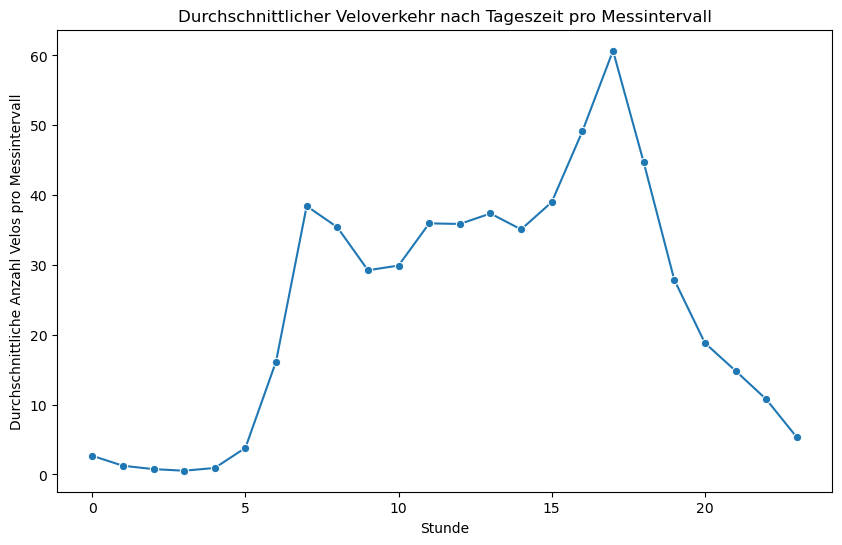

In [36]:
hourly = data.groupby("stunde")["anzahl"].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=hourly, x="stunde", y="anzahl", marker="o")
plt.title("Durchschnittlicher Veloverkehr nach Tageszeit pro Messintervall")
plt.xlabel("Stunde")
plt.ylabel("Durchschnittliche Anzahl Velos pro Messintervall")

plt.savefig("../visuals/hourly_bike_traffic.png", dpi=300, bbox_inches="tight")

plt.show()


Die Analyse nach Tageszeit zeigt, zu welchen Stunden im Durchschnitt besonders viele Velos gezählt werden. Solche Muster können auf Pendlerverkehr oder typische Mobilitätszeiten hinweisen.

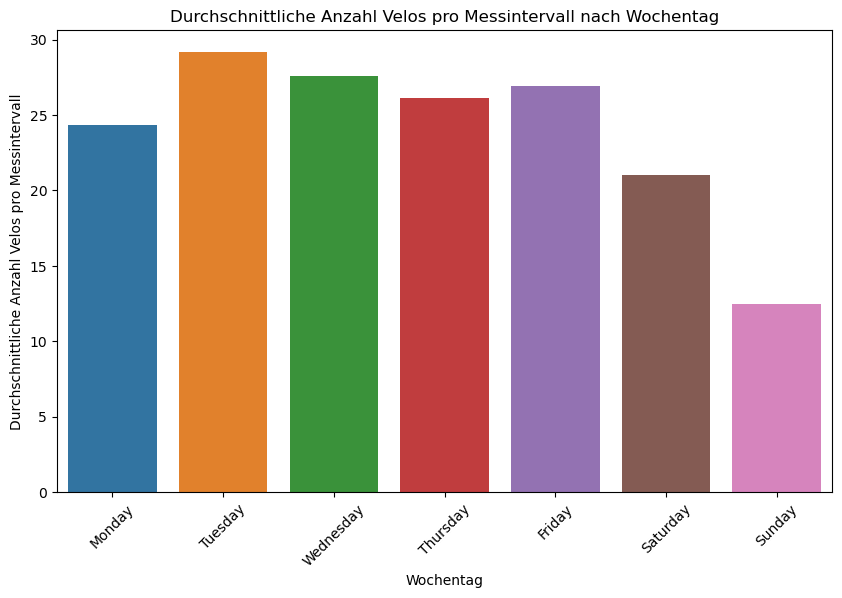

In [10]:
weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday", 
    "Friday", "Saturday", "Sunday"
]

weekday = data.groupby("wochentag_name")["anzahl"].mean().reindex(weekday_order).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=weekday, x="wochentag_name", y="anzahl")
plt.title("Durchschnittliche Anzahl Velos pro Messintervall nach Wochentag")
plt.xlabel("Wochentag")
plt.ylabel("Durchschnittliche Anzahl Velos pro Messintervall")
plt.xticks(rotation=45)
plt.show()

Der Vergleich nach Wochentagen zeigt Unterschiede zwischen Werktagen und Wochenende. Dadurch lässt sich erkennen, ob der Veloverkehr stärker durch Pendlerverkehr oder Freizeitverkehr geprägt ist.

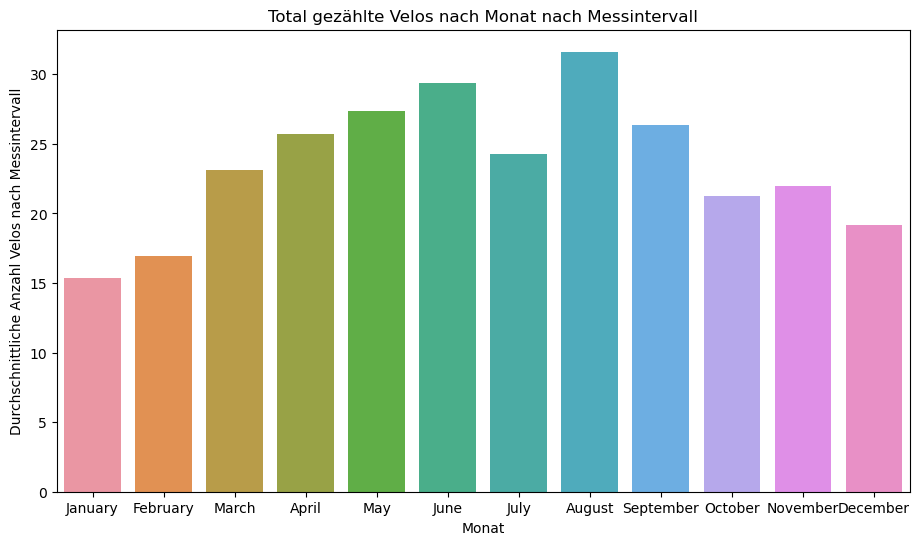

In [11]:
month_order = [
    "January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"
]

monthly = data.groupby("monat_name")["anzahl"].mean().reindex(month_order).reset_index()

plt.figure(figsize=(11, 6))
sns.barplot(data=monthly, x="monat_name", y="anzahl")
plt.title("Total gezählte Velos nach Monat nach Messintervall")
plt.xlabel("Monat")
plt.ylabel("Durchschnittliche Anzahl Velos nach Messintervall")
plt.show()

Der Monatsvergleich zeigt saisonale Unterschiede im durchschnittlichen Veloverkehr pro Messintervall. Höhere Werte in wärmeren Monaten könnten auf wetter- und saisonabhängiges Mobilitätsverhalten hindeuten.

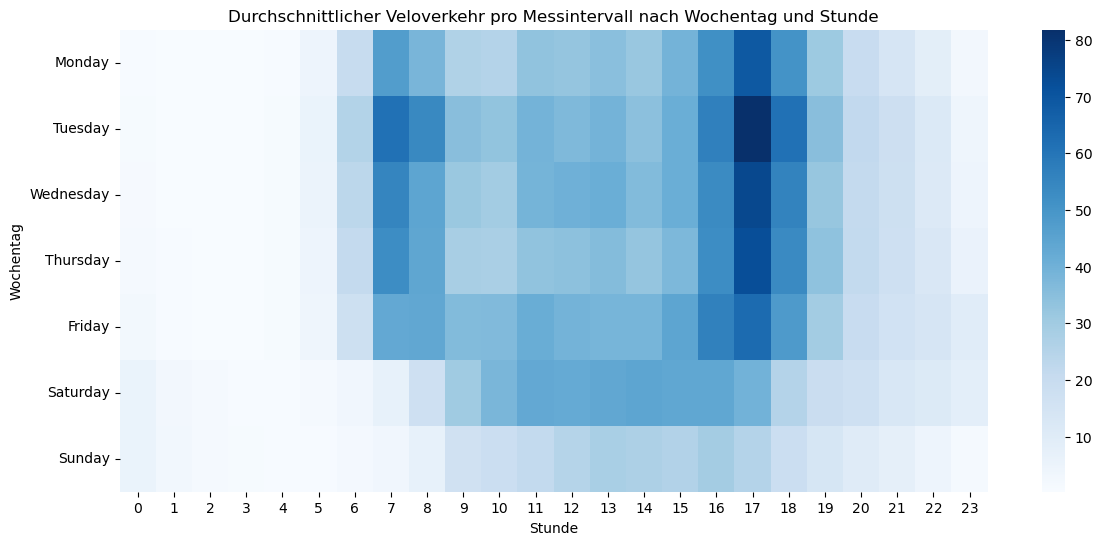

In [ ]:
heatmap_data = data.pivot_table(
    values="anzahl",
    index="wochentag_name",
    columns="stunde",
    aggfunc="mean"
)

heatmap_data = heatmap_data.reindex(weekday_order)

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, cmap="Blues")
plt.title("Durchschnittlicher Veloverkehr pro Messintervall nach Wochentag und Stunde")
plt.xlabel("Stunde")
plt.ylabel("Wochentag")

plt.savefig("../visuals/heatmap_weekday_hour.png", dpi=300, bbox_inches="tight")

plt.show()

In [13]:
data.drop(columns=["anlage_nr", "spur_nr"], inplace=True)

In [14]:
data.head()

,gemeinde_bfs_nr,gemeinde,anlage_name,anlage_typ,zeit_von,zeit_bis,richtung,richtung_name,lat,lon,anzahl,stunde,wochentag_nr,wochentag_name,monat_nr,monat_name
0,230,Winterthur,Unterführung Bahnhof,Velo,2026-06-10 23:00:00+01:00,2026-06-10T23:59:59+01,O,Richtung Unterführung raus,47.500640,8.725399,20,23,2,Wednesday,6,June
1,230,Winterthur,Unterführung Bahnhof,Velo,2026-06-10 23:00:00+01:00,2026-06-10T23:59:59+01,W,Richtung Unterführung rein,47.500640,8.725399,9,23,2,Wednesday,6,June
2,230,Winterthur,K501 Velo - Seenerstrasse,Velo,2026-06-10 23:00:00+01:00,2026-06-10T23:59:59+01,N,Richtung Oberwinterthur,47.493335,8.760645,0,23,2,Wednesday,6,June
3,230,Winterthur,K501 Velo - Seenerstrasse,Velo,2026-06-10 23:00:00+01:00,2026-06-10T23:59:59+01,S,Richtung Seen,47.493335,8.760645,4,23,2,Wednesday,6,June
4,230,Winterthur,Frohbergstrasse,Velo,2026-06-10 23:00:00+01:00,2026-06-10T23:59:59+01,-,Richtung Meisenstrasse,47.497110,8.726561,3,23,2,Wednesday,6,June


In [15]:
data.drop(columns=["anlage_typ", "richtung_name", "lat", "lon"], inplace = True)

## 5. Vorbereitung für Machine Learning

Da die Zielvariable `anzahl` eine numerische Grösse ist, handelt es sich um ein Regressionsproblem. Ziel ist es, die Anzahl gezählter Velos pro Messintervall anhand der verfügbaren Features vorherzusagen.

In [16]:
X = data[["monat_nr", "wochentag_nr", "stunde"]].values

In [17]:
y = data["anzahl"].values

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## 6. Modellvergleich

Um ein geeignetes Modell auszuwählen, werden mehrere Regressionsmodelle miteinander verglichen. Bewertet werden die Modelle anhand von MAE, RMSE und R².

Der MAE zeigt, um wie viele Velos das Modell im Durchschnitt danebenliegt. RMSE bestraft grössere Fehler stärker. R² zeigt, wie viel Varianz der Zielvariable durch das Modell erklärt wird.

In [19]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

In [33]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"])
results_df = results_df.sort_values("MAE")

plt.savefig("../visuals/model_comparison_mae.png", dpi=300, bbox_inches="tight")

results_df

,Model,MAE,RMSE,R2
1,Decision Tree,21.856426,36.073196,0.212199
2,Random Forest,21.863666,36.081141,0.211852
0,Linear Regression,25.519434,39.850398,0.038581


<Figure size 640x480 with 0 Axes>

Der Decision Tree Regressor erzielte im Vergleich den tiefsten MAE. Da der Unterschied zum Random Forest jedoch gering ist, wird das Ergebnis vorsichtig interpretiert.

## 7. Hyperparameter-Tuning

Decision Trees können bei zu grosser Baumtiefe overfitten. Deshalb wird die maximale Baumtiefe `max_depth` mit Cross-Validation getestet. Ziel ist es, eine Baumtiefe zu finden, die eine gute Vorhersageleistung erzielt, ohne zu komplex zu werden.

In [21]:
depths = [2, 3, 4, 5, 6, 8, 10, 12, 15, 20]

results = []

for depth in depths:
    model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="neg_mean_absolute_error"
    )
    
    mae_scores = -scores
    
    results.append({
        "max_depth": depth,
        "mean_cv_mae": mae_scores.mean(),
        "std_cv_mae": mae_scores.std()
    })

depth_results = pd.DataFrame(results)
depth_results.sort_values("mean_cv_mae")

,max_depth,mean_cv_mae,std_cv_mae
6,10,21.763538,0.149755
5,8,21.798718,0.198928
7,12,21.810670,0.148969
8,15,21.932116,0.150551
4,6,21.968270,0.202290
9,20,22.001351,0.145844
3,5,22.110050,0.202416
2,4,22.316405,0.219057
1,3,22.546291,0.205983
0,2,22.958110,0.221736


Die Cross-Validation zeigt, dass Baumtiefe 10 im Durchschnitt den tiefsten MAE erreicht. Die gewählte Baumtiefe wird anschliessend für das finale Modell verwendet.

In [22]:
f_model = DecisionTreeRegressor(max_depth= 10, random_state=42)

In [23]:
f_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=10, random_state=42)

In [24]:
y_pred_train = f_model.predict(X_train)
y_pred_test = f_model.predict(X_test)

## 8. Evaluation des finalen Modells

Das finale Modell wird auf Trainingsdaten und Testdaten bewertet. Dadurch kann geprüft werden, ob das Modell overfittet oder ob es auf neuen Daten ähnlich gut funktioniert.

In [32]:
train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

score_comparison = pd.DataFrame({
    "Dataset": ["In-Sample / Train", "Out-of-Sample / Test"],
    "MAE": [train_mae, test_mae],
    "RMSE": [train_rmse, test_rmse],
    "R2": [train_r2, test_r2]
})



plt.savefig("../visuals/in_out_sample_error.png", dpi=300, bbox_inches="tight")

score_comparison

,Dataset,MAE,RMSE,R2
0,In-Sample / Train,21.565072,35.695950,0.243075
1,Out-of-Sample / Test,21.614997,35.627917,0.231527


<Figure size 640x480 with 0 Axes>

Die Fehlerwerte auf Trainings- und Testdaten sind sehr ähnlich. Das spricht dafür, dass kein starkes Overfitting vorliegt. Der MAE von rund 21 bedeutet, dass das Modell im Durchschnitt um etwa 21 Velos pro Messintervall danebenliegt.

Das R² von rund 0.23 zeigt jedoch, dass die verwendeten Features nur einen Teil der Schwankungen im Veloverkehr erklären können.

## 9. Feature Importance

Die Feature Importance zeigt, welche Variablen im Decision Tree besonders stark zur Vorhersage beitragen.

In [26]:
features  = ["monat_nr", "wochentag_nr", "stunde"]

importance = pd.DataFrame({
    "Feature": features,
    "Importance": f_model.feature_importances_
}).sort_values("Importance", ascending=False)

importance

,Feature,Importance
2,stunde,0.786121
1,wochentag_nr,0.149035
0,monat_nr,0.064844


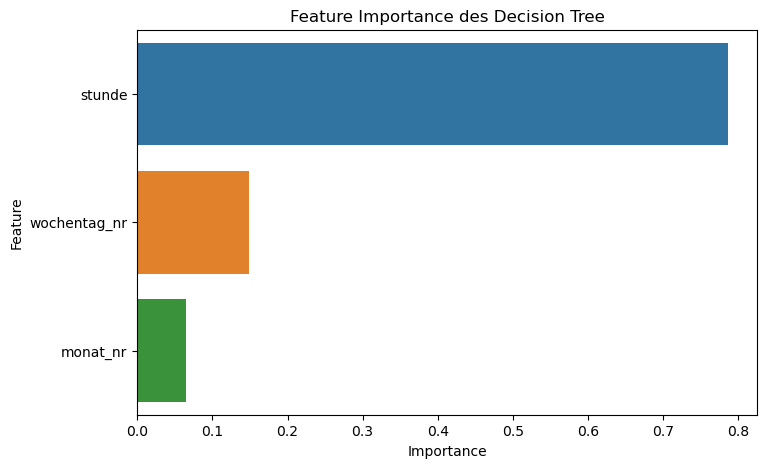

In [27]:
plt.figure(figsize=(8, 5))
sns.barplot(data=importance, x="Importance", y="Feature")
plt.title("Feature Importance des Decision Tree")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## 10. Fehleranalyse

Neben den klassischen Kennzahlen wird untersucht, wie sich die Vorhersagefehler verteilen und wie stark die vorhergesagten Werte von den tatsächlichen Werten abweichen.

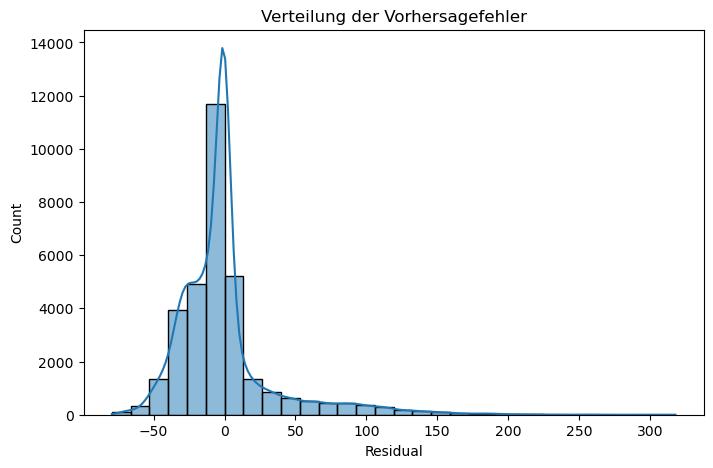

In [28]:
residuals = y_test - y_pred_test

plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=30, kde=True)
plt.title("Verteilung der Vorhersagefehler")
plt.xlabel("Residual")
plt.show()

## 11. Fazit und Limitationen

In diesem Projekt wurden reale Veloverkehrsdaten der Stadt Winterthur analysiert und für ein einfaches Regressionsmodell verwendet. Die explorative Analyse zeigt zeitliche Muster nach Stunde, Wochentag und Monat.

Im Modellvergleich schnitt der Decision Tree Regressor am besten ab. Nach dem Hyperparameter-Tuning wurde das finale Modell anhand von Trainings- und Testdaten bewertet. Die ähnlichen Fehlerwerte auf beiden Datensätzen zeigen, dass kein starkes Overfitting vorliegt.

Der MAE von rund 21 bedeutet, dass das Modell im Durchschnitt um etwa 21 Velos pro Messintervall danebenliegt. Das R² von rund 0.23 zeigt jedoch, dass die verwendeten Features nur einen Teil der Schwankungen erklären können.

Eine wichtige Limitation ist, dass externe Einflussfaktoren wie Wetter, Feiertage, Schulferien oder Events nicht im Modell enthalten sind. Diese Faktoren könnten die Vorhersagequalität in einem nächsten Schritt verbessern.